In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("retail_store_inventory.csv")
print(df.shape)
df.head()

(73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [3]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [4]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].min(), df['Date'].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [6]:
df.duplicated().sum()

0

In [7]:
df['Category'].value_counts()

Furniture      14699
Toys           14643
Clothing       14626
Groceries      14611
Electronics    14521
Name: Category, dtype: int64

In [8]:
df['Region'].value_counts()

East     18349
South    18297
North    18228
West     18226
Name: Region, dtype: int64

In [9]:
df['Store ID'].nunique(), df['Product ID'].nunique()

(5, 20)

## Day 1 — Data Overview & Quality Check

- 73,100 rows, 15 columns: daily records for 5 stores × 20 products over 2 years (2022-01-01 to 2024-01-01)
- No missing values, no duplicate rows
- Date column converted from text to datetime
- Categories and regions are well balanced
- Data quality flags for later:
  - Inventory Level never goes below 50 → need a custom low-stock threshold, not "==0"
  - Demand Forecast has negative values (min -9.99) → likely needs clipping/capping

In [10]:
df['Demand Forecast'] = df['Demand Forecast'].clip(lower=0)


In [11]:
df['Demand Forecast'].min()

0.0

In [12]:
df = df.sort_values(['Store ID', 'Product ID', 'Date'])

In [13]:
df['Sell_Through_Rate'] = df['Units Sold'] / (df['Units Sold'] + df['Inventory Level'])

In [14]:
df['Avg_Daily_Demand_7d'] = (
    df.groupby(['Store ID', 'Product ID'])['Units Sold']
      .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

In [15]:
df['Stock_Cover_Days'] = df['Inventory Level'] / df['Avg_Daily_Demand_7d'].replace(0, np.nan)

In [16]:
df[['Store ID', 'Product ID', 'Date', 'Inventory Level', 'Units Sold', 'Avg_Daily_Demand_7d', 'Stock_Cover_Days', 'Sell_Through_Rate']].head(10)

,Store ID,Product ID,Date,Inventory Level,Units Sold,Avg_Daily_Demand_7d,Stock_Cover_Days,Sell_Through_Rate
0,S001,P0001,2022-01-01,231,127,127.000000,1.818898,0.354749
100,S001,P0001,2022-01-02,116,81,104.000000,1.115385,0.411168
200,S001,P0001,2022-01-03,154,5,71.000000,2.169014,0.031447
300,S001,P0001,2022-01-04,85,58,67.750000,1.254613,0.405594
400,S001,P0001,2022-01-05,238,147,83.600000,2.846890,0.381818
500,S001,P0001,2022-01-06,198,37,75.833333,2.610989,0.157447
600,S001,P0001,2022-01-07,195,107,80.285714,2.428826,0.354305
700,S001,P0001,2022-01-08,231,2,62.428571,3.700229,0.008584
800,S001,P0001,2022-01-09,373,350,100.857143,3.698300,0.484094
900,S001,P0001,2022-01-10,327,36,105.285714,3.105834,0.099174


In [17]:
df['Low_Stock_Flag'] = np.where(df['Stock_Cover_Days'] < 3, 1, 0)
df['Low_Stock_Flag'].value_counts(normalize=True)

1    0.795691
0    0.204309
Name: Low_Stock_Flag, dtype: float64

In [18]:
df['Stock_Cover_Days'].describe()

count    73099.000000
mean         2.158983
std          1.266517
min          0.201439
25%          1.252345
50%          1.997429
75%          2.798631
max         58.333333
Name: Stock_Cover_Days, dtype: float64

In [19]:
threshold = df.groupby(['Store ID', 'Product ID'])['Stock_Cover_Days'].transform(lambda x: x.quantile(0.25))
df['Low_Stock_Flag'] = np.where(df['Stock_Cover_Days'] < threshold, 1, 0)
df['Low_Stock_Flag'].value_counts(normalize=True)


0    0.749672
1    0.250328
Name: Low_Stock_Flag, dtype: float64

In [20]:
product_sales = df.groupby('Product ID')['Units Sold'].sum().sort_values(ascending=False)
product_sales


Product ID
P0016    508472
P0020    507708
P0014    507622
P0015    507283
P0005    503648
P0009    502086
P0013    500619
P0017    500510
P0011    499362
P0007    499321
P0001    498061
P0019    497899
P0006    497131
P0010    496469
P0004    495501
P0003    493279
P0018    492551
P0012    491670
P0008    488563
P0002    487827
Name: Units Sold, dtype: int64

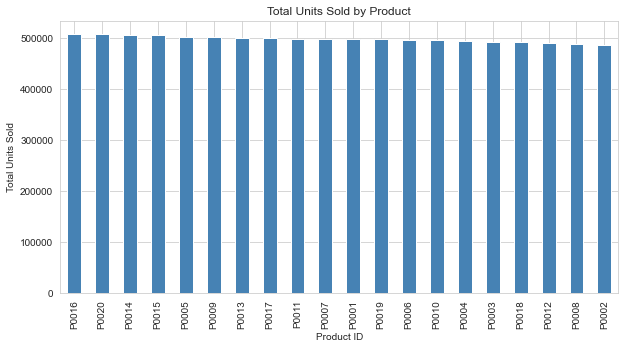

In [21]:
plt.figure(figsize=(10,5))
product_sales.plot(kind='bar', color='steelblue')
plt.title('Total Units Sold by Product')
plt.xlabel('Product ID')
plt.ylabel('Total Units Sold')
plt.show()

In [22]:
df.groupby('Category')['Low_Stock_Flag'].mean().sort_values(ascending=False)

Category
Groceries      0.252276
Electronics    0.251704
Clothing       0.250923
Toys           0.249334
Furniture      0.247432
Name: Low_Stock_Flag, dtype: float64

In [23]:
df.groupby('Region')['Low_Stock_Flag'].mean().sort_values(ascending=False)

Region
West     0.251893
South    0.250150
East     0.250041
North    0.249232
Name: Low_Stock_Flag, dtype: float64

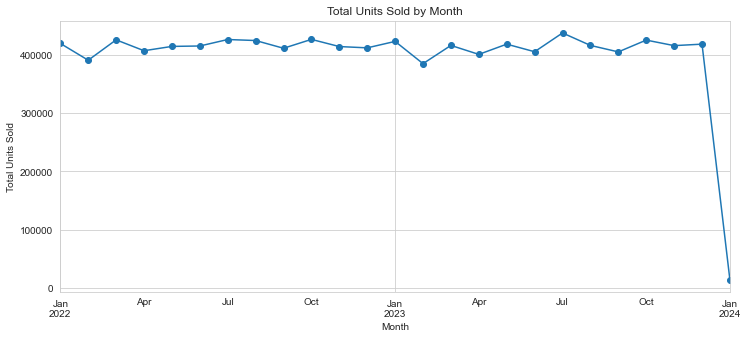

In [24]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Units Sold'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Total Units Sold by Month')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.show()

In [25]:
df.groupby('Holiday/Promotion')['Units Sold'].mean()

Holiday/Promotion
0    136.505375
1    136.423926
Name: Units Sold, dtype: float64

In [26]:
df.groupby('Weather Condition')['Units Sold'].mean().sort_values(ascending=False)

Weather Condition
Sunny     138.028650
Cloudy    136.758324
Snowy     135.911559
Rainy     135.160028
Name: Units Sold, dtype: float64

In [27]:
from scipy import stats

sunny = df[df['Weather Condition'] == 'Sunny']['Units Sold']
rainy = df[df['Weather Condition'] == 'Rainy']['Units Sold']

t_stat, p_value = stats.ttest_ind(sunny, rainy)
print("p-value:", p_value)

p-value: 0.01184526718397506


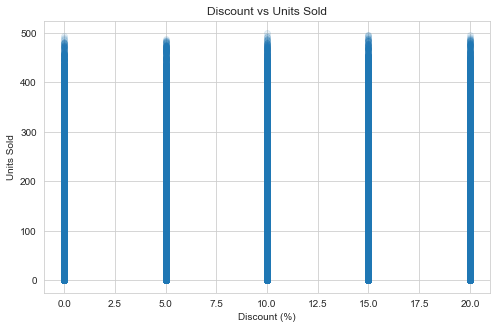

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Units Sold'], alpha=0.1)
plt.title('Discount vs Units Sold')
plt.xlabel('Discount (%)')
plt.ylabel('Units Sold')
plt.show()

In [29]:
df['Discount'].corr(df['Units Sold'])

0.0025756510203161016

## Day 3 — EDA Findings

- Sales are evenly distributed across products, categories, and regions (no ABC/Pareto pattern)
- Monthly sales trend is flat/stable across 2 years (Jan 2024 shows an artificial drop — only 1 day of data, not a real decline)
- Holiday/Promotion showed no measurable lift in sales (136.5 vs 136.4 avg units)
- Weather showed a statistically significant but practically small effect (p=0.012, ~2% difference) — not actionable on its own
- Discount level has no relationship with units sold (r=0.003) — different pattern than Project 1's discount-driven margin story

In [30]:
safety_stock = (
    df.groupby(['Store ID', 'Product ID'])['Units Sold']
      .std()
      .fillna(0) * 1.65
)
safety_stock.head()

Store ID  Product ID
S001      P0001         178.509967
          P0002         172.116813
          P0003         176.898521
          P0004         187.512793
          P0005         177.158640
Name: Units Sold, dtype: float64

In [31]:
avg_demand = df.groupby(['Store ID', 'Product ID'])['Units Sold'].mean()
lead_time_days = 5   # assumption: takes 5 days for new stock to arrive

reorder_point = (avg_demand * lead_time_days) + safety_stock
reorder_point.head()

Store ID  Product ID
S001      P0001         865.042115
          P0002         827.308331
          P0003         884.100984
          P0004         892.033997
          P0005         842.808435
Name: Units Sold, dtype: float64

In [32]:
latest = df[df['Date'] == df['Date'].max()]
latest = latest.set_index(['Store ID', 'Product ID'])

comparison = pd.DataFrame({
    'Current_Inventory': latest['Inventory Level'],
    'Reorder_Point': reorder_point
})

comparison['Needs_Reorder'] = comparison['Current_Inventory'] < comparison['Reorder_Point']
comparison.sort_values('Needs_Reorder', ascending=False).head(15)

Current_Inventory  Reorder_Point  Needs_Reorder
Store ID Product ID                                                 
S001     P0001                     223     865.042115           True
S004     P0004                     105     832.105434           True
         P0014                     386     893.841624           True
         P0013                     113     829.949348           True
         P0012                      85     830.405411           True
         P0011                     155     874.621735           True
         P0010                     382     872.342404           True
         P0009                     115     858.620872           True
         P0008                     390     849.298646           True
         P0007                     134     826.539747           True
         P0006                     364     884.439933           True
         P0005                     217     862.795473           True
         P0003                     419     823.242430           True
S001     P0002                     217     827.308331           True
S004     P0002                     181     822.926672           True

In [33]:
lead_time_days = 2   # revised assumption, based on max inventory (~500) vs daily demand (~150-190)

reorder_point = (avg_demand * lead_time_days) + safety_stock
reorder_point.head()

Store ID  Product ID
S001      P0001         453.122826
          P0002         434.193420
          P0003         459.779506
          P0004         469.321275
          P0005         443.418558
Name: Units Sold, dtype: float64

In [34]:
comparison = pd.DataFrame({
    'Current_Inventory': latest['Inventory Level'],
    'Reorder_Point': reorder_point
})

comparison['Needs_Reorder'] = comparison['Current_Inventory'] < comparison['Reorder_Point']
comparison['Needs_Reorder'].value_counts(normalize=True)

True     0.92
False    0.08
Name: Needs_Reorder, dtype: float64

In [35]:
lead_time_days = 1     # revised again — even shorter, matching how thin their stock levels run
z_score = 1.0           # revised safety margin — targets a lower ~84% service level instead of 95%, matching the tight inventory levels we observe

safety_stock = (
    df.groupby(['Store ID', 'Product ID'])['Units Sold']
      .std()
      .fillna(0) * z_score
)

avg_demand = df.groupby(['Store ID', 'Product ID'])['Units Sold'].mean()
reorder_point = (avg_demand * lead_time_days) + safety_stock

comparison = pd.DataFrame({
    'Current_Inventory': latest['Inventory Level'],
    'Reorder_Point': reorder_point
})
comparison['Needs_Reorder'] = comparison['Current_Inventory'] < comparison['Reorder_Point']
comparison['Needs_Reorder'].value_counts(normalize=True)

False    0.53
True     0.47
Name: Needs_Reorder, dtype: float64

In [36]:
at_risk = comparison[comparison['Needs_Reorder'] == True].sort_values('Current_Inventory')
at_risk.head(15)

Current_Inventory  Reorder_Point  Needs_Reorder
Store ID Product ID                                                 
S002     P0007                      53     250.392760           True
S004     P0015                      56     245.908834           True
S005     P0007                      59     250.314731           True
S002     P0009                      62     256.574833           True
S004     P0019                      65     247.096333           True
S001     P0003                      69     248.651718           True
         P0016                      74     240.471899           True
S004     P0018                      83     232.339198           True
         P0012                      85     235.734283           True
S005     P0016                      96     250.866675           True
         P0003                      98     256.477075           True
S004     P0017                     100     243.226565           True
S003     P0008                     103     243.635476           True
S004     P0004                     105     238.189423           True
S003     P0007                     108     249.589519           True

## Day 4 — Reorder Point & Safety Stock Analysis

- Built safety stock (based on demand variability) and reorder points (lead time × avg demand + safety stock)
- Initial assumptions (5-day lead time, 95% service level) were unrealistic for this business's actual inventory scale — revised to 1-day lead time, ~84% service level after checking against observed stock levels
- 47% of Store-Product combinations are currently below their reorder point
- Identified the 15 most urgent restock priorities, ranked by current inventory level (e.g. Store S002/Product P0007 at only 53 units vs a reorder point of 250)

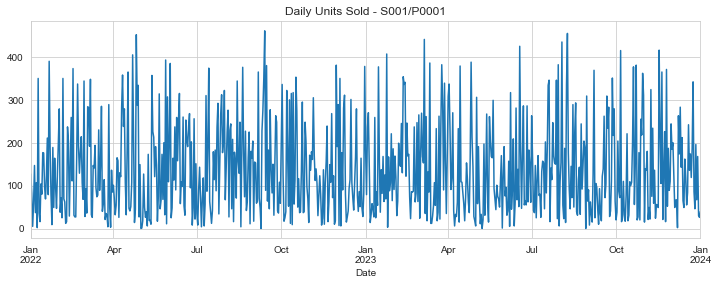

In [37]:
sample = df[(df['Store ID'] == 'S001') & (df['Product ID'] == 'P0001')].copy()
sample = sample.set_index('Date')
sample['Units Sold'].plot(figsize=(12,4), title='Daily Units Sold - S001/P0001')
plt.show()

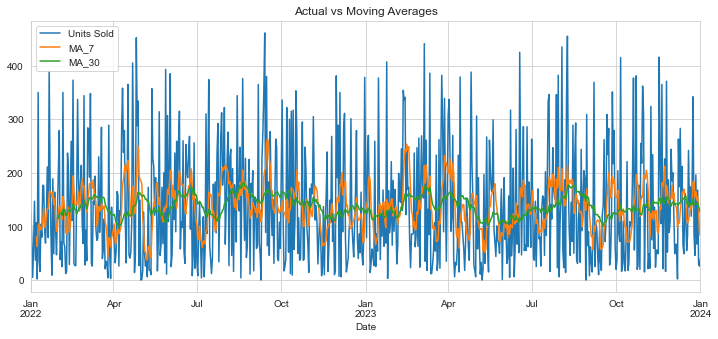

In [38]:
sample['MA_7'] = sample['Units Sold'].rolling(window=7).mean()
sample['MA_30'] = sample['Units Sold'].rolling(window=30).mean()

sample[['Units Sold', 'MA_7', 'MA_30']].plot(figsize=(12,5), title='Actual vs Moving Averages')
plt.show()



C:\Users\amrut\AppData\Local\Programs\Python\Python36\lib\site-packages\statsmodels\tsa\base\tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)
C:\Users\amrut\AppData\Local\Programs\Python\Python36\lib\site-packages\statsmodels\tsa\holtwinters\model.py:429: FutureWarning: After 0.13 initialization must be handled at model creation
  FutureWarning,


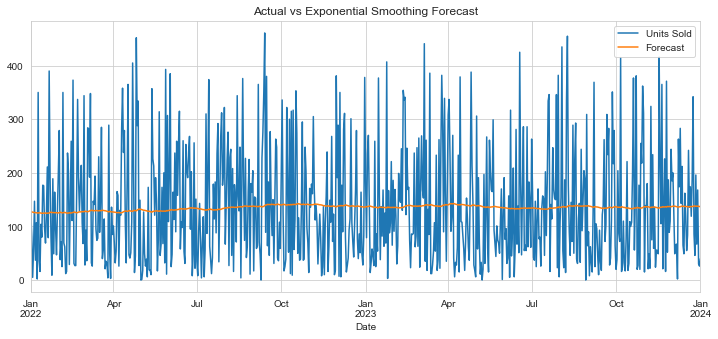

In [39]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(sample['Units Sold'], trend=None, seasonal=None)
fit = model.fit()

sample['Forecast'] = fit.fittedvalues

sample[['Units Sold', 'Forecast']].plot(figsize=(12,5), title='Actual vs Exponential Smoothing Forecast')
plt.show()

In [40]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae = mean_absolute_error(sample['Units Sold'], sample['Forecast'])
mape = mean_absolute_percentage_error(sample['Units Sold'], sample['Forecast'])

print("MAE:", mae)
print("MAPE:", mape)

MAE: 89.45471496688134
MAPE: 3357942692484537.5


In [41]:
print("Average daily sales:", sample['Units Sold'].mean())
print("MAE as % of average sales:", (mae / sample['Units Sold'].mean()) * 100)

Average daily sales: 137.3064295485636
MAE as % of average sales: 65.14969128611877


In [42]:
weekly = sample['Units Sold'].resample('W').sum()

model_weekly = ExponentialSmoothing(weekly, trend=None, seasonal=None)
fit_weekly = model_weekly.fit()
weekly_forecast = fit_weekly.fittedvalues

mae_weekly = mean_absolute_error(weekly, weekly_forecast)
print("Weekly MAE:", mae_weekly)
print("Weekly MAE as % of average weekly sales:", (mae_weekly / weekly.mean()) * 100)

Weekly MAE: 245.3144644165993
Weekly MAE as % of average weekly sales: 25.907217451414777


C:\Users\amrut\AppData\Local\Programs\Python\Python36\lib\site-packages\statsmodels\tsa\holtwinters\model.py:429: FutureWarning: After 0.13 initialization must be handled at model creation
  FutureWarning,


## Day 5 — Demand Forecasting

- Built moving average (7-day, 30-day) and exponential smoothing forecasts for a sample product (S001/P0001)
- Daily-level forecast had high error (MAE ≈ 65% of average daily sales) — daily demand is highly noisy
- Weekly-level forecast performed much better (MAE ≈ 26% of average weekly sales) — aggregating over time cancels out random daily noise
- Conclusion: weekly demand forecasts are more reliable than daily forecasts for inventory planning decisions at the SKU level
- Note: standard MAPE was unusable due to zero-sales days; used MAE and a custom "% of average sales" metric instead

In [43]:
df.to_csv("inventory_analysis_full.csv", index=False)

In [44]:
at_risk_export = at_risk.reset_index()
at_risk_export.to_csv("at_risk_products.csv", index=False)

In [45]:
weekly_export = pd.DataFrame({
    'Week': weekly.index,
    'Actual': weekly.values,
    'Forecast': weekly_forecast.values
})
weekly_export.to_csv("weekly_forecast.csv", index=False)

In [51]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly_export = df.groupby('Month')['Units Sold'].sum().reset_index()
monthly_export.to_csv("monthly_sales.csv", index=False)

In [52]:
monthly_export

,Month,Units Sold
0,2022-01,419938
1,2022-02,391052
2,2022-03,426073
3,2022-04,407380
4,2022-05,414799
5,2022-06,415509
6,2022-07,426628
7,2022-08,424916
8,2022-09,411610
9,2022-10,426863


In [53]:
comparison_export = comparison.reset_index()
comparison_export.to_csv("reorder_comparison_full.csv", index=False)